# Olist E-Commerce Delivery Analysis

## 1. Environment Setup

This notebook analyzes delivery performance within the Olist Brazilian
e-commerce dataset.

The analysis focuses on completed orders and examines delivery speed,
estimated-versus-actual delivery performance, late-delivery patterns,
geographic differences, and selected logistics-related factors.

The objective is to identify operational patterns that may help explain
delivery performance and highlight potential areas for improvement.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
PROJECT_ROOT = Path("..")
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

PROCESSED_DATA_DIR

PosixPath('../data/processed')

## 2. Load Processed Datasets

The delivery analysis primarily operates at the **order level**.

The processed `orders` dataset provides the main delivery lifecycle
timestamps, while order-item, customer, seller, and geographic datasets are
loaded for selected logistics and geographic analyses.

Care is taken to preserve dataset grain when combining these tables because
orders may contain multiple items and may involve multiple sellers.

In [3]:
orders = pd.read_csv(
    PROCESSED_DATA_DIR / "orders.csv"
)

order_items = pd.read_csv(
    PROCESSED_DATA_DIR / "order_items.csv"
)

customers = pd.read_csv(
    PROCESSED_DATA_DIR / "customers.csv"
)

sellers = pd.read_csv(
    PROCESSED_DATA_DIR / "sellers.csv"
)

geolocation_zip = pd.read_csv(
    PROCESSED_DATA_DIR / "geolocation_zip.csv"
)

### 2.1 Parse Delivery Lifecycle Timestamps

Order lifecycle fields are converted to datetime format before delivery
metrics are calculated.

The primary timestamps used in the analysis are:

- `order_purchase_timestamp`
- `order_approved_at`
- `order_delivered_carrier_date`
- `order_delivered_customer_date`
- `order_estimated_delivery_date`

In [4]:
order_datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in order_datetime_columns:
    orders[column] = pd.to_datetime(
        orders[column],
        errors="coerce"
    )

In [5]:
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Customers:", customers.shape)
print("Sellers:", sellers.shape)
print("Geolocation ZIP:", geolocation_zip.shape)

Orders: (99441, 8)
Order Items: (112650, 7)
Customers: (99441, 8)
Sellers: (3095, 7)
Geolocation ZIP: (19011, 4)


In [6]:
orders[
    [
        "order_id",
        "customer_id",
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [7]:
print(
    "Order records:",
    len(orders)
)

print(
    "Unique order IDs:",
    orders["order_id"].nunique()
)

print(
    "Duplicate order IDs:",
    orders["order_id"].duplicated().sum()
)

Order records: 99441
Unique order IDs: 99441
Duplicate order IDs: 0


In [8]:
delivery_timestamp_missing = (
    orders[
        [
            "order_purchase_timestamp",
            "order_approved_at",
            "order_delivered_carrier_date",
            "order_delivered_customer_date",
            "order_estimated_delivery_date"
        ]
    ]
    .isna()
    .sum()
    .to_frame("missing_values")
)

delivery_timestamp_missing["missing_pct"] = (
    delivery_timestamp_missing["missing_values"]
    / len(orders)
    * 100
)

delivery_timestamp_missing

,missing_values,missing_pct
order_purchase_timestamp,0,0.00
order_approved_at,160,0.16
order_delivered_carrier_date,1783,1.79
order_delivered_customer_date,2965,2.98
order_estimated_delivery_date,0,0.00


In [9]:
delivered_orders = (
    orders[
        orders["order_status"] == "delivered"
    ]
    .copy()
)

print(
    "Delivered orders:",
    len(delivered_orders)
)

print(
    "Unique delivered order IDs:",
    delivered_orders["order_id"].nunique()
)

Delivered orders: 96478
Unique delivered order IDs: 96478


In [10]:
delivered_timestamp_missing = (
    delivered_orders[
        [
            "order_purchase_timestamp",
            "order_approved_at",
            "order_delivered_carrier_date",
            "order_delivered_customer_date",
            "order_estimated_delivery_date"
        ]
    ]
    .isna()
    .sum()
    .to_frame("missing_values")
)

delivered_timestamp_missing["missing_pct"] = (
    delivered_timestamp_missing["missing_values"]
    / len(delivered_orders)
    * 100
)

delivered_timestamp_missing

,missing_values,missing_pct
order_purchase_timestamp,0,0.00
order_approved_at,14,0.01
order_delivered_carrier_date,2,0.00
order_delivered_customer_date,8,0.01
order_estimated_delivery_date,0,0.00


### Initial Delivery Dataset Validation — Key Findings

The processed datasets were loaded successfully, including **99,441 orders**
and **112,650 order-item records**.

The `orders` dataset contains **99,441 unique order IDs** with no duplicate
order records, confirming a grain of **one row per order**.

Among all orders, missing delivery lifecycle timestamps are primarily
associated with carrier handoff and customer delivery dates. However, timestamp
coverage is substantially more complete among delivered orders.

The dataset contains **96,478 delivered orders**. Within this population:

- `order_purchase_timestamp` has no missing values
- `order_estimated_delivery_date` has no missing values
- `order_approved_at` is missing for **14 orders**
- `order_delivered_carrier_date` is missing for **2 orders**
- `order_delivered_customer_date` is missing for **8 orders**

Because the missing lifecycle timestamps affect only a small number of
delivered orders, records will not be removed globally. Instead, each delivery
metric will use the subset of delivered orders containing the timestamps
required for that specific calculation.

This approach preserves the maximum valid order population while avoiding
unnecessary data loss.

## 3. Delivery Analysis Definitions

Delivery performance is evaluated using the order lifecycle timestamps available
in the processed `orders` dataset.

The analysis focuses primarily on delivered orders because actual delivery
performance can only be measured when a customer delivery timestamp is
available.

The main delivery metrics are defined as follows:

- **Total Delivery Time**: Time from order purchase to customer delivery
- **Carrier Handoff Time**: Time from order approval to carrier handoff
- **Carrier-to-Customer Time**: Time from carrier handoff to customer delivery
- **Estimated Delivery Window**: Time from order purchase to the estimated
  delivery date
- **Delivery Variance**: Actual customer delivery time relative to the estimated
  delivery date
- **On-Time Delivery**: Actual customer delivery occurred on or before the
  estimated delivery date
- **Late Delivery**: Actual customer delivery occurred after the estimated
  delivery date

Metrics are calculated at the **order level**. Each metric uses only the
delivered orders containing the timestamps required for that specific
calculation.

### 3.1 Define the Core Delivery Population

The core delivery population consists of orders with `order_status` equal to
`delivered`.

Delivered orders are retained as the starting population even when an
individual lifecycle timestamp is missing. Metric-specific subsets are created
later according to the timestamps required for each calculation.

In [11]:
delivery_orders = (
    orders[
        orders["order_status"] == "delivered"
    ]
    .copy()
)

print(
    "Core delivered-order population:",
    len(delivery_orders)
)

print(
    "Unique delivered order IDs:",
    delivery_orders["order_id"].nunique()
)

print(
    "Duplicate order IDs:",
    delivery_orders["order_id"].duplicated().sum()
)

Core delivered-order population: 96478
Unique delivered order IDs: 96478
Duplicate order IDs: 0


### 3.2 Define Metric-Specific Valid Populations

In [12]:
valid_total_delivery = (
    delivery_orders[
        delivery_orders[
            [
                "order_purchase_timestamp",
                "order_delivered_customer_date"
            ]
        ]
        .notna()
        .all(axis=1)
    ]
    .copy()
)

In [13]:
valid_carrier_handoff = (
    delivery_orders[
        delivery_orders[
            [
                "order_approved_at",
                "order_delivered_carrier_date"
            ]
        ]
        .notna()
        .all(axis=1)
    ]
    .copy()
)

In [14]:
valid_carrier_delivery = (
    delivery_orders[
        delivery_orders[
            [
                "order_delivered_carrier_date",
                "order_delivered_customer_date"
            ]
        ]
        .notna()
        .all(axis=1)
    ]
    .copy()
)

In [15]:
valid_delivery_performance = (
    delivery_orders[
        delivery_orders[
            [
                "order_delivered_customer_date",
                "order_estimated_delivery_date"
            ]
        ]
        .notna()
        .all(axis=1)
    ]
    .copy()
)

In [16]:
valid_population_summary = pd.DataFrame(
    {
        "metric": [
            "Total Delivery Time",
            "Carrier Handoff Time",
            "Carrier-to-Customer Time",
            "On-Time / Late Delivery"
        ],
        "valid_orders": [
            len(valid_total_delivery),
            len(valid_carrier_handoff),
            len(valid_carrier_delivery),
            len(valid_delivery_performance)
        ]
    }
)

valid_population_summary["coverage_pct"] = (
    valid_population_summary["valid_orders"]
    / len(delivery_orders)
    * 100
)

valid_population_summary

,metric,valid_orders,coverage_pct
0,Total Delivery Time,96470,99.99
1,Carrier Handoff Time,96462,99.98
2,Carrier-to-Customer Time,96469,99.99
3,On-Time / Late Delivery,96470,99.99


### 3.3 Calculate Preliminary Delivery Durations

In [17]:
valid_total_delivery["total_delivery_days"] = (
    (
        valid_total_delivery["order_delivered_customer_date"]
        - valid_total_delivery["order_purchase_timestamp"]
    )
    .dt.total_seconds()
    / 86400
)

In [18]:
valid_carrier_handoff["carrier_handoff_days"] = (
    (
        valid_carrier_handoff["order_delivered_carrier_date"]
        - valid_carrier_handoff["order_approved_at"]
    )
    .dt.total_seconds()
    / 86400
)

In [19]:
valid_carrier_delivery["carrier_to_customer_days"] = (
    (
        valid_carrier_delivery["order_delivered_customer_date"]
        - valid_carrier_delivery["order_delivered_carrier_date"]
    )
    .dt.total_seconds()
    / 86400
)

In [20]:
valid_delivery_performance["delivery_variance_days"] = (
    (
        valid_delivery_performance["order_delivered_customer_date"]
        - valid_delivery_performance["order_estimated_delivery_date"]
    )
    .dt.total_seconds()
    / 86400
)

### 3.4 Validate Duration Logic

In [21]:
duration_validation = pd.DataFrame(
    {
        "metric": [
            "Total Delivery Time",
            "Carrier Handoff Time",
            "Carrier-to-Customer Time"
        ],
        "negative_values": [
            (valid_total_delivery["total_delivery_days"] < 0).sum(),
            (valid_carrier_handoff["carrier_handoff_days"] < 0).sum(),
            (valid_carrier_delivery["carrier_to_customer_days"] < 0).sum()
        ],
        "zero_values": [
            (valid_total_delivery["total_delivery_days"] == 0).sum(),
            (valid_carrier_handoff["carrier_handoff_days"] == 0).sum(),
            (valid_carrier_delivery["carrier_to_customer_days"] == 0).sum()
        ]
    }
)

duration_validation

,metric,negative_values,zero_values
0,Total Delivery Time,0,0
1,Carrier Handoff Time,1350,0
2,Carrier-to-Customer Time,23,9


#### 3.4.1 Investigate Negative Duration Records

Negative delivery durations indicate that some recorded lifecycle timestamps
do not follow the expected operational sequence.

In particular, a negative Carrier Handoff Time means that the recorded carrier
handoff occurred before order approval, while a negative Carrier-to-Customer
Time means that customer delivery was recorded before carrier handoff.

These records are investigated before any exclusion decision is made.

In [22]:
negative_handoff = (
    valid_carrier_handoff[
        valid_carrier_handoff["carrier_handoff_days"] < 0
    ]
    .copy()
)

negative_handoff["carrier_handoff_hours"] = (
    negative_handoff["carrier_handoff_days"] * 24
)

print(
    "Negative carrier handoff records:",
    len(negative_handoff)
)

negative_handoff["carrier_handoff_hours"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

Negative carrier handoff records: 1350


count    1,350.00
mean       -24.70
std        115.66
min     -4,109.26
1%        -165.95
5%         -83.95
10%        -51.49
25%        -25.95
50%        -17.16
75%         -1.41
90%         -0.54
95%         -0.28
99%         -0.07
max         -0.01
Name: carrier_handoff_hours, dtype: float64

In [23]:
negative_handoff[
    [
        "order_id",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "carrier_handoff_hours"
    ]
].sort_values(
    "carrier_handoff_hours"
).head(20)

,order_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,carrier_handoff_hours
25883,7c48bb55e8e4f7e56d412e9653db37bc,2018-07-16 18:40:53,2018-07-16 18:50:22,2018-01-26 13:35:00,2018-07-23 20:04:45,"-4,109.26"
14562,1fab4ac9d85079b3da72a11475ae1685,2017-09-01 19:04:22,2017-09-13 22:06:11,2017-09-04 13:10:23,2017-09-08 20:13:03,-224.93
46163,0184d4ddb259e1a4cfc2871888cf97b8,2017-09-01 20:04:28,2017-09-13 22:17:15,2017-09-04 14:05:50,2017-09-09 15:12:44,-224.19
98710,1378f9601350615613cc8832d6789c5d,2017-09-01 20:28:02,2017-09-13 22:03:51,2017-09-04 18:07:55,2017-09-13 22:24:46,-219.93
41592,8554cb37f7158cb0b082a841d24a4589,2017-09-01 18:40:44,2017-09-13 21:58:04,2017-09-04 19:12:19,2017-09-08 20:07:45,-218.76
11738,cf72398d0690f841271b695bbfda82d2,2017-09-01 18:45:33,2017-09-13 22:04:39,2017-09-04 20:12:41,2017-09-11 14:15:02,-217.87
85393,40de47dfa620d667117e4a6067b6e1ec,2017-09-01 20:05:55,2017-09-13 21:58:38,2017-09-04 20:36:58,2017-09-08 20:41:16,-217.36
31211,bc4854efd86d9f42140c951c595d20c1,2017-09-01 20:05:42,2017-09-13 22:00:51,2017-09-04 20:49:57,2017-09-06 22:15:45,-217.18
55302,77ca435b03fbf991e5027e3776e37885,2017-09-01 18:49:54,2017-09-13 21:56:08,2017-09-04 20:50:00,2017-09-30 17:33:43,-217.10
68315,580f3268bc2075c5961b2d2929c7a35b,2017-09-01 20:17:09,2017-09-13 22:03:42,2017-09-05 11:58:18,2017-09-18 17:52:20,-202.09


In [24]:
negative_carrier_delivery = (
    valid_carrier_delivery[
        valid_carrier_delivery["carrier_to_customer_days"] < 0
    ]
    .copy()
)

negative_carrier_delivery["carrier_to_customer_hours"] = (
    negative_carrier_delivery["carrier_to_customer_days"] * 24
)

print(
    "Negative carrier-to-customer records:",
    len(negative_carrier_delivery)
)

negative_carrier_delivery[
    "carrier_to_customer_hours"
].describe()

Negative carrier-to-customer records: 23


count     23.00
mean     -78.46
std       89.31
min     -386.31
25%     -128.76
50%      -39.86
75%      -23.34
max       -0.39
Name: carrier_to_customer_hours, dtype: float64

In [25]:
negative_carrier_delivery[
    [
        "order_id",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "carrier_to_customer_hours"
    ]
].sort_values(
    "carrier_to_customer_hours"
)

,order_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,carrier_to_customer_hours
34939,c1e2bf2b7dd3309f2f5356c6b63968fa,2017-02-10 10:19:10,2017-02-10 10:30:13,2017-03-02 17:34:26,2017-02-14 15:15:57,-386.31
27470,fa3e37584f4fdb1ded0e0de700dfcb4e,2017-07-30 19:32:23,2017-07-30 19:45:09,2017-08-09 18:18:43,2017-08-01 21:13:01,-189.09
45302,29941903985f944b0ffc49c479c1547d,2017-05-29 16:16:50,2017-05-29 16:25:16,2017-06-09 15:07:29,2017-06-02 11:09:16,-171.97
14474,dceb62e8fa94b46006c9554fed743df0,2017-07-20 20:58:05,2017-07-22 11:45:11,2017-08-01 18:23:30,2017-07-26 18:09:10,-144.24
49933,76458889992169d3135b264dc13aec67,2016-10-07 10:05:16,2016-10-07 11:24:43,2016-10-26 11:43:06,2016-10-20 18:03:17,-137.66
71227,19feb5627c41ea1b36a8e50a469b3644,2016-10-07 17:09:56,2016-10-07 17:32:09,2016-10-26 11:42:05,2016-10-20 19:07:54,-136.57
74967,d5558a097766363b8e76b38c43332e8a,2017-02-04 19:01:33,2017-02-04 19:31:12,2017-02-15 08:55:26,2017-02-10 07:58:32,-120.95
41636,b866af202be0692766081310cd4085e1,2017-01-27 14:59:17,2017-01-27 15:30:46,2017-02-20 02:32:08,2017-02-15 03:53:46,-118.64
6437,a1abeb653a4d4cd1e142ccb8c82cd069,2017-07-20 11:20:52,2017-07-21 06:43:14,2017-07-28 16:57:58,2017-07-25 19:32:56,-69.42
78556,ea1dcb4757a844d2642547797bd5feb0,2017-07-18 13:38:29,2017-07-18 13:50:23,2017-07-27 19:21:31,2017-07-25 19:43:10,-47.64


In [26]:
negative_duration_rates = pd.DataFrame(
    {
        "metric": [
            "Carrier Handoff Time",
            "Carrier-to-Customer Time"
        ],
        "valid_orders": [
            len(valid_carrier_handoff),
            len(valid_carrier_delivery)
        ],
        "negative_records": [
            len(negative_handoff),
            len(negative_carrier_delivery)
        ]
    }
)

negative_duration_rates["negative_pct"] = (
    negative_duration_rates["negative_records"]
    / negative_duration_rates["valid_orders"]
    * 100
)

negative_duration_rates

,metric,valid_orders,negative_records,negative_pct
0,Carrier Handoff Time,96462,1350,1.40
1,Carrier-to-Customer Time,96469,23,0.02


#### 3.4.2 Define Valid Duration Records

Timestamp validation identified lifecycle-sequence anomalies in selected
delivery-stage metrics.

Among orders with the required timestamps:

- **1,350 orders (1.40%)** have a negative Carrier Handoff Time
- **23 orders (0.02%)** have a negative Carrier-to-Customer Time
- No negative Total Delivery Time values were identified

The negative Carrier Handoff values are not limited to minor timestamp
differences. Although the median negative interval is approximately
**17.16 hours**, some records show substantially larger inconsistencies,
including an extreme value of approximately **4,109 hours**.

Negative Carrier-to-Customer intervals also include material inconsistencies,
with a minimum of approximately **-386.31 hours**.

Because these timestamps violate the expected order lifecycle sequence, they
are excluded only from the specific stage-duration metrics they invalidate.
The corresponding orders are retained for other delivery metrics when the
required timestamps remain valid.

Zero Carrier-to-Customer durations are retained because same-time carrier
handoff and customer delivery records do not inherently violate chronological
ordering.

In [27]:
analysis_total_delivery = (
    valid_total_delivery[
        valid_total_delivery["total_delivery_days"] >= 0
    ]
    .copy()
)

In [28]:
analysis_carrier_handoff = (
    valid_carrier_handoff[
        valid_carrier_handoff["carrier_handoff_days"] >= 0
    ]
    .copy()
)

In [29]:
analysis_carrier_delivery = (
    valid_carrier_delivery[
        valid_carrier_delivery["carrier_to_customer_days"] >= 0
    ]
    .copy()
)

In [30]:
analysis_delivery_performance = (
    valid_delivery_performance.copy()
)

In [31]:
analysis_population_summary = pd.DataFrame(
    {
        "metric": [
            "Total Delivery Time",
            "Carrier Handoff Time",
            "Carrier-to-Customer Time",
            "On-Time / Late Delivery"
        ],
        "valid_timestamp_orders": [
            len(valid_total_delivery),
            len(valid_carrier_handoff),
            len(valid_carrier_delivery),
            len(valid_delivery_performance)
        ],
        "analysis_orders": [
            len(analysis_total_delivery),
            len(analysis_carrier_handoff),
            len(analysis_carrier_delivery),
            len(analysis_delivery_performance)
        ]
    }
)

analysis_population_summary["excluded_anomalies"] = (
    analysis_population_summary["valid_timestamp_orders"]
    - analysis_population_summary["analysis_orders"]
)

analysis_population_summary["coverage_of_delivered_pct"] = (
    analysis_population_summary["analysis_orders"]
    / len(delivery_orders)
    * 100
)

analysis_population_summary

,metric,valid_timestamp_orders,analysis_orders,excluded_anomalies,coverage_of_delivered_pct
0,Total Delivery Time,96470,96470,0,99.99
1,Carrier Handoff Time,96462,95112,1350,98.58
2,Carrier-to-Customer Time,96469,96446,23,99.97
3,On-Time / Late Delivery,96470,96470,0,99.99


#### Final Analysis Population

After timestamp availability and chronological consistency checks, each
delivery metric uses its own valid analysis population.

Coverage remains above **98.5% of delivered orders for all metrics**. The
largest adjustment occurs in Carrier Handoff Time, where **1,350 records**
with negative approval-to-carrier intervals are excluded.

These exclusions are metric-specific. Orders with invalid intermediate
lifecycle timestamps remain eligible for other delivery metrics when the
timestamps required for those calculations are valid.

### 3.5 Delivery Duration Summary

After excluding metric-specific chronological anomalies, the distributions of
the main delivery-duration metrics are examined.

These descriptive statistics are used to evaluate typical delivery performance
and identify potential skewness or extreme values before aggregate KPIs are
reported.

In [32]:
duration_summary = pd.DataFrame(
    {
        "Total Delivery Time": (
            analysis_total_delivery["total_delivery_days"].describe()
        ),
        "Carrier Handoff Time": (
            analysis_carrier_handoff["carrier_handoff_days"].describe()
        ),
        "Carrier-to-Customer Time": (
            analysis_carrier_delivery["carrier_to_customer_days"].describe()
        ),
        "Delivery Variance": (
            analysis_delivery_performance["delivery_variance_days"].describe()
        )
    }
)

duration_summary

,Total Delivery Time,Carrier Handoff Time,Carrier-to-Customer Time,Delivery Variance
count,"96,470.00","95,112.00","96,446.00","96,470.00"
mean,12.56,2.85,9.33,-11.18
std,9.55,3.49,8.76,10.18
min,0.53,0.00,0.00,-146.02
25%,6.77,0.90,4.10,-16.24
50%,10.22,1.85,7.10,-11.95
75%,15.72,3.62,12.03,-6.39
max,209.63,125.76,205.19,188.98


#### Delivery Duration Distribution — Key Findings

After excluding metric-specific chronological anomalies, delivered orders take
an average of **12.56 days** from purchase to customer delivery, with a median
of **10.22 days**.

The average Carrier Handoff Time is **2.85 days**, while the average
Carrier-to-Customer Time is **9.33 days**. This indicates that the
carrier-to-customer stage accounts for a substantial portion of the overall
delivery cycle.

For the main delivery-duration metrics, mean values exceed their corresponding
medians, indicating right-skewed distributions influenced by relatively slow
delivery cases. Total Delivery Time reaches a maximum of approximately
**209.63 days**, compared with a median of **10.22 days**.

Delivery Variance, defined as actual delivery timestamp minus estimated
delivery timestamp, has a mean of **-11.18 days** and a median of
**-11.95 days**. The negative values indicate that deliveries generally occur
before the estimated delivery deadline. Early and late deliveries are analyzed
separately in the following sections rather than interpreting this overall
average as a standalone performance KPI.

### 3.6 On-Time vs Late Delivery Definition

The estimated delivery field is recorded at the start of the estimated calendar
date, while actual customer delivery timestamps include a time of day.

A direct timestamp comparison would therefore classify an order delivered later
on its estimated delivery date as late, even though it arrived on the promised
calendar date.

To avoid this classification issue, timestamp-based and calendar-date-based
definitions are compared before the final on-time delivery rule is selected.

#### 3.6.1 Compare Timestamp-Based and Date-Based Classification

In [33]:
analysis_delivery_performance["actual_delivery_date"] = (
    analysis_delivery_performance[
        "order_delivered_customer_date"
    ].dt.normalize()
)

analysis_delivery_performance["estimated_delivery_date"] = (
    analysis_delivery_performance[
        "order_estimated_delivery_date"
    ].dt.normalize()
)

In [34]:
analysis_delivery_performance["on_time_timestamp"] = (
    analysis_delivery_performance["order_delivered_customer_date"]
    <= analysis_delivery_performance["order_estimated_delivery_date"]
)

In [35]:
analysis_delivery_performance["on_time_date"] = (
    analysis_delivery_performance["actual_delivery_date"]
    <= analysis_delivery_performance["estimated_delivery_date"]
)

In [36]:
classification_difference = (
    analysis_delivery_performance["on_time_timestamp"]
    != analysis_delivery_performance["on_time_date"]
)

print(
    "Orders classified differently:",
    classification_difference.sum()
)

print(
    "Difference rate:",
    f"{classification_difference.mean() * 100:.2f}%"
)

Orders classified differently: 1292
Difference rate: 1.34%


In [37]:
analysis_delivery_performance.loc[
    classification_difference,
    [
        "order_id",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "on_time_timestamp",
        "on_time_date"
    ]
].head(20)

,order_id,order_delivered_customer_date,order_estimated_delivery_date,on_time_timestamp,on_time_date
35,8563039e855156e48fccee4d611a3196,2018-03-20 00:59:25,2018-03-20,False,True
152,1d067305b599c1e0dceb3864056ea527,2018-03-09 21:52:36,2018-03-09,False,True
226,c82a457d646f77c8f151e12a3e517ed2,2018-08-15 15:02:09,2018-08-15,False,True
269,2c3a5e5f5bc3ae78ed5748461e62d47d,2018-02-06 15:49:01,2018-02-06,False,True
357,6cc4eb51469dec50a6130fe1cd07b7f9,2017-05-19 15:55:47,2017-05-19,False,True
385,5342acb7b183acec77f59e4d78f7c804,2018-04-24 16:10:44,2018-04-24,False,True
404,884b1394fc8888e6a877df86eb19e74c,2018-03-29 17:32:05,2018-03-29,False,True
655,2f4545bda1b1c794a9a35a3fbe4257ba,2018-06-05 15:38:50,2018-06-05,False,True
753,1a4cc55b483d875e3b8bbd64a1b31bba,2018-05-09 15:08:44,2018-05-09,False,True
762,ed24759a0ae96582e88fdca0c0997d22,2018-04-23 14:57:48,2018-04-23,False,True


#### Final On-Time Delivery Definition

A direct timestamp comparison classifies **1,292 orders (1.34%)** differently
from a calendar-date comparison.

Inspection of these records shows that they were delivered on the estimated
delivery date but later than midnight. Because the estimated delivery field is
recorded at the start of the promised calendar date, a timestamp-based
comparison would incorrectly classify these same-day deliveries as late.

Therefore, the final delivery classification uses calendar dates:

- **On Time**: Actual delivery date is on or before the estimated delivery date
- **Late**: Actual delivery date is after the estimated delivery date

This definition better reflects the business meaning of a promised delivery
date and avoids artificial late-delivery classifications caused by differences
in timestamp granularity.

#### 3.6.2 Create Final Delivery Classification

In [38]:
analysis_delivery_performance["delivery_status"] = np.where(
    analysis_delivery_performance["actual_delivery_date"]
    <= analysis_delivery_performance["estimated_delivery_date"],
    "On Time",
    "Late"
)

In [39]:
analysis_delivery_performance["delivery_difference_days"] = (
    analysis_delivery_performance["actual_delivery_date"]
    - analysis_delivery_performance["estimated_delivery_date"]
).dt.days

#### 3.6.3 Validate Final Classification

In [40]:
delivery_status_summary = (
    analysis_delivery_performance["delivery_status"]
    .value_counts()
    .rename_axis("delivery_status")
    .reset_index(name="orders")
)

delivery_status_summary["percentage"] = (
    delivery_status_summary["orders"]
    / delivery_status_summary["orders"].sum()
    * 100
)

delivery_status_summary

,delivery_status,orders,percentage
0,On Time,89936,93.23
1,Late,6534,6.77


In [41]:
classification_validation = pd.DataFrame(
    {
        "check": [
            "On-Time orders with positive difference",
            "Late orders with non-positive difference"
        ],
        "records": [
            (
                (
                    analysis_delivery_performance["delivery_status"] == "On Time"
                )
                & (
                    analysis_delivery_performance["delivery_difference_days"] > 0
                )
            ).sum(),
            (
                (
                    analysis_delivery_performance["delivery_status"] == "Late"
                )
                & (
                    analysis_delivery_performance["delivery_difference_days"] <= 0
                )
            ).sum()
        ]
    }
)

classification_validation

,check,records
0,On-Time orders with positive difference,0
1,Late orders with non-positive difference,0


### 3.7 Final Delivery Metric Definitions

The final delivery metrics used throughout the analysis are:

| Metric | Definition |
|---|---|
| Total Delivery Time | Customer delivery timestamp − purchase timestamp |
| Carrier Handoff Time | Carrier handoff timestamp − approval timestamp |
| Carrier-to-Customer Time | Customer delivery timestamp − carrier handoff timestamp |
| Delivery Difference | Actual delivery calendar date − estimated delivery calendar date |
| On-Time Delivery | Actual delivery date ≤ estimated delivery date |
| Late Delivery | Actual delivery date > estimated delivery date |

Negative intermediate lifecycle durations that violate chronological ordering
are excluded only from the affected stage-duration metric.

The final analysis therefore preserves valid orders wherever possible while
maintaining chronological consistency for each delivery KPI.

## 4. Delivery Performance Overview

This section summarizes the key delivery performance indicators for completed
orders.

The analysis focuses on four business questions:

1. How long does a typical order take to reach the customer?
2. What percentage of delivered orders arrive on time?
3. How early do on-time orders typically arrive?
4. How severe are delays among late orders?

These metrics provide a concise overview of delivery reliability and customer
fulfillment performance.

### 4.1 Overall Delivery KPIs

Overall delivery performance is summarized using both average and median
delivery time, together with the final calendar-date-based on-time
classification defined in Section 3.

In [42]:
average_delivery_days = (
    analysis_total_delivery["total_delivery_days"].mean()
)

median_delivery_days = (
    analysis_total_delivery["total_delivery_days"].median()
)

on_time_orders = (
    analysis_delivery_performance["delivery_status"]
    .eq("On Time")
    .sum()
)

late_orders = (
    analysis_delivery_performance["delivery_status"]
    .eq("Late")
    .sum()
)

total_classified_orders = len(analysis_delivery_performance)

on_time_rate = (
    on_time_orders / total_classified_orders * 100
)

late_rate = (
    late_orders / total_classified_orders * 100
)

In [43]:
delivery_kpi_summary = pd.DataFrame(
    {
        "KPI": [
            "Average Delivery Time (Days)",
            "Median Delivery Time (Days)",
            "On-Time Delivery Rate (%)",
            "Late Delivery Rate (%)"
        ],
        "Value": [
            average_delivery_days,
            median_delivery_days,
            on_time_rate,
            late_rate
        ]
    }
)

delivery_kpi_summary

,KPI,Value
0,Average Delivery Time (Days),12.56
1,Median Delivery Time (Days),10.22
2,On-Time Delivery Rate (%),93.23
3,Late Delivery Rate (%),6.77


### 4.2 Early vs Late Delivery Performance

Delivery performance is further divided into three calendar-date outcomes:

- **Early**: Delivered before the estimated delivery date
- **On Estimated Date**: Delivered exactly on the estimated delivery date
- **Late**: Delivered after the estimated delivery date

This distinction separates genuinely early deliveries from orders that arrived
exactly on the promised date.

In [44]:
analysis_delivery_performance["delivery_timing"] = np.select(
    [
        analysis_delivery_performance["delivery_difference_days"] < 0,
        analysis_delivery_performance["delivery_difference_days"] == 0,
        analysis_delivery_performance["delivery_difference_days"] > 0
    ],
    [
        "Early",
        "On Estimated Date",
        "Late"
    ],
    default="Unknown"
)

In [45]:
delivery_timing_summary = (
    analysis_delivery_performance["delivery_timing"]
    .value_counts()
    .reindex(["Early", "On Estimated Date", "Late"])
    .rename_axis("delivery_timing")
    .reset_index(name="orders")
)

delivery_timing_summary["percentage"] = (
    delivery_timing_summary["orders"]
    / delivery_timing_summary["orders"].sum()
    * 100
)

delivery_timing_summary

,delivery_timing,orders,percentage
0,Early,88644,91.89
1,On Estimated Date,1292,1.34
2,Late,6534,6.77


#### 4.2.1 Average Days Early / Late

In [46]:
early_orders = analysis_delivery_performance[
    analysis_delivery_performance["delivery_difference_days"] < 0
]

late_orders_detail = analysis_delivery_performance[
    analysis_delivery_performance["delivery_difference_days"] > 0
]

average_days_early = (
    -early_orders["delivery_difference_days"].mean()
)

median_days_early = (
    -early_orders["delivery_difference_days"].median()
)

average_days_late = (
    late_orders_detail["delivery_difference_days"].mean()
)

median_days_late = (
    late_orders_detail["delivery_difference_days"].median()
)

In [47]:
delivery_timing_kpis = pd.DataFrame(
    {
        "KPI": [
            "Average Days Early",
            "Median Days Early",
            "Average Days Late",
            "Median Days Late"
        ],
        "Value": [
            average_days_early,
            median_days_early,
            average_days_late,
            median_days_late
        ]
    }
)

delivery_timing_kpis

,KPI,Value
0,Average Days Early,13.71
1,Median Days Early,13.00
2,Average Days Late,10.62
3,Median Days Late,7.00


### 4.3 Delivery Timing Distribution

The distribution below shows the proportion of delivered orders that arrived
early, on the estimated delivery date, or late.

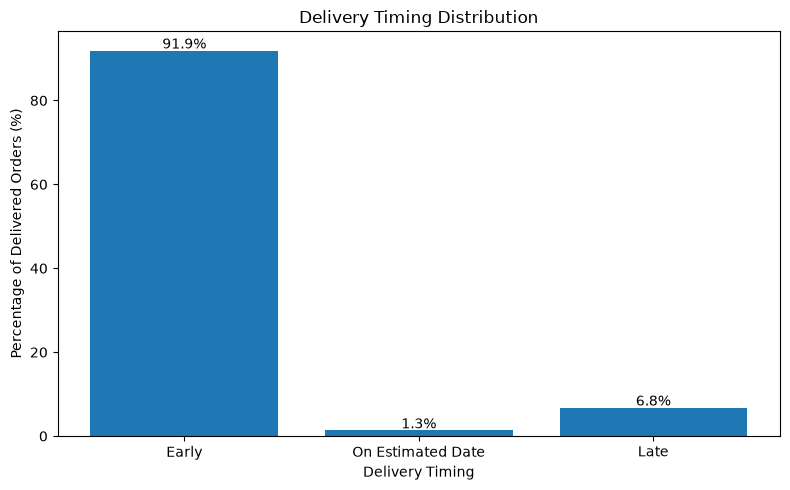

In [48]:
timing_plot = delivery_timing_summary.copy()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    timing_plot["delivery_timing"],
    timing_plot["percentage"]
)

plt.title("Delivery Timing Distribution")
plt.xlabel("Delivery Timing")
plt.ylabel("Percentage of Delivered Orders (%)")

for bar, value in zip(bars, timing_plot["percentage"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

### 4.4 Delivery Time Distribution

The distribution of total delivery time is examined to distinguish typical
delivery performance from unusually slow deliveries.

Because the distribution contains a small number of extreme values, the chart
focuses on orders within the 99th percentile of total delivery time for
visual clarity. The underlying records are retained in the analysis.

In [49]:
delivery_time_p99 = (
    analysis_total_delivery["total_delivery_days"]
    .quantile(0.99)
)

delivery_time_p99

np.float64(46.05026180555554)

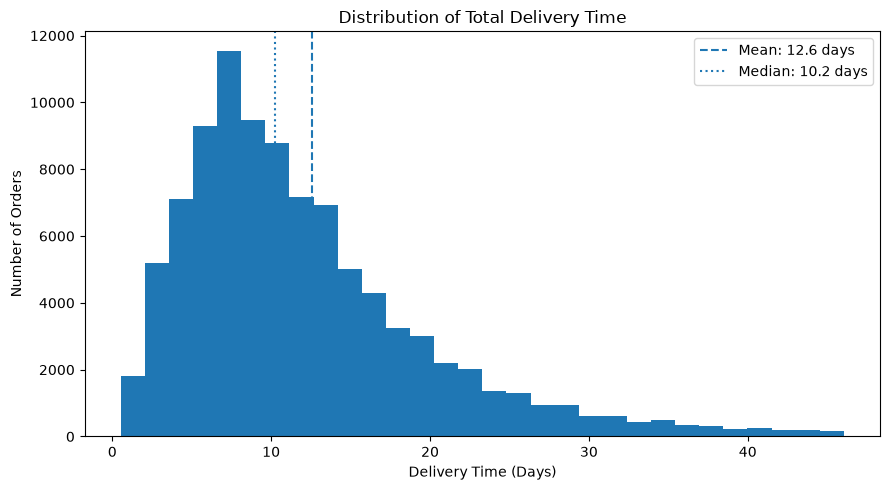

In [51]:
delivery_time_plot = analysis_total_delivery[
    analysis_total_delivery["total_delivery_days"]
    <= delivery_time_p99
]

plt.figure(figsize=(9, 5))

plt.hist(
    delivery_time_plot["total_delivery_days"],
    bins=30
)

plt.axvline(
    average_delivery_days,
    linestyle="--",
    label=f"Mean: {average_delivery_days:.1f} days"
)

plt.axvline(
    median_delivery_days,
    linestyle=":",
    label=f"Median: {median_delivery_days:.1f} days"
)

plt.title("Distribution of Total Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")
plt.legend()

plt.tight_layout()
plt.show()

## 5. Delivery Analysis Summary & Business Insights

The delivery analysis evaluates fulfillment speed and delivery reliability
across completed Olist orders. Overall, delivery performance is strong, with
most orders arriving before their estimated delivery dates. However, a smaller
group of delayed and unusually slow deliveries remains operationally relevant.

### Key Findings

- Delivered orders take an average of **12.56 days** to reach customers, while
  the median delivery time is **10.22 days**. The higher mean indicates a
  right-skewed distribution influenced by slower delivery cases.

- **93.23%** of delivered orders arrive on or before the estimated delivery
  date, while **6.77%** are delivered late.

- Most delivered orders (**91.89%**) arrive before the estimated delivery date,
  while **1.34%** arrive exactly on the estimated date.

- Early deliveries arrive an average of **13.71 days ahead of the estimated
  delivery date**, with a median of **13 days early**.

- Late deliveries arrive an average of **10.62 days after the estimated
  delivery date**, with a median delay of **7 days**.

- The 99th percentile of total delivery time is approximately **46.05 days**,
  showing that a relatively small group of orders experiences substantially
  longer delivery times.

- Delivery-stage analysis shows an average **Carrier Handoff Time of 2.85 days**
  and an average **Carrier-to-Customer Time of 9.33 days**, indicating that the
  carrier-to-customer stage represents a substantial portion of the overall
  delivery cycle.

### Business Implications

Overall delivery reliability is high, with more than nine out of ten delivered
orders meeting or beating the estimated delivery date. This suggests that the
current estimated delivery dates generally provide sufficient time for order
fulfillment.

However, late deliveries remain important because delayed orders arrive an
average of more than **10 days after the estimated date**. Operational
monitoring should therefore focus not only on the late-delivery rate but also
on the severity of delays among affected orders.

The large share of early deliveries also suggests that estimated delivery dates
may be conservative for many orders. More accurate delivery estimates could
provide customers with more realistic expectations while maintaining a high
level of delivery reliability.

Finally, the longer carrier-to-customer stage suggests that downstream logistics
may represent an important area for further operational investigation. Future
analysis could examine geographic differences, seller locations, freight costs,
and carrier-related factors to better understand the causes of slow deliveries.

### Analysis Limitations

- Delivery performance is evaluated only for orders with the timestamps required
  for each metric.

- Records with chronologically inconsistent intermediate timestamps are excluded
  only from the affected stage-duration metrics rather than removed globally.

- On-time performance is based on calendar dates because estimated delivery
  timestamps are recorded at midnight while actual delivery timestamps include
  time-of-day information.

- The analysis identifies descriptive delivery patterns but does not establish
  causal relationships between logistics factors and delivery delays.

### Conclusion

Olist demonstrates strong overall delivery reliability, with **93.23% of
delivered orders arriving on time**. Nevertheless, the relatively long delays
among late orders and the right-skewed delivery-time distribution indicate that
a smaller group of fulfillment cases may require operational attention.

These findings provide a concise baseline for monitoring delivery performance
and identifying opportunities to improve delivery estimates and reduce severe
delays.